---
title: Data-Centric AI (Module II)
subtitle: "From Domain Features to Automated Feature Selection"
---

## Learning outcomes

By the end of this notebook, you should be able to:

- Create reproducible manual features.
- Integrate feature construction into a pipeline.
- Distinguish feature engineering from feature selection.
- Compare filter and wrapper selection methods.
- Evaluate predictive performance, stability, and computational cost.

## 1. Feature engineering versus feature selection

**Feature engineering** creates candidate inputs for a model. It turns domain knowledge into measurable variables: ratios, differences, calendar effects, interaction terms, nonlinear transformations, and aggregations.

**Feature selection** chooses a subset of candidate inputs. It tries to keep signal while removing redundancy, noise, computational cost, and sources of overfitting.

A useful feature usually has at least one of these properties:

- It carries **signal** about the target.
- It is not just a duplicate of another feature.
- It is stable across samples, folds, and time periods.
- It is available at the moment the model is used.
- It does not encode the answer through leakage.

Feature engineering introduces hypotheses about the problem; feature selection controls complexity. Neither should inspect validation or test data.

# [What personal data is considered sensitive](https://commission.europa.eu/law/law-topic/data-protection/reform/rules-business-and-organisations/legal-grounds-processing-data/sensitive-data/what-personal-data-considered-sensitive_en)?

The following personal data is considered *sensitive* and is subject to specific processing conditions:

- personal data revealing racial or ethnic origin, political opinions, religious or philosophical beliefs;
- trade-union membership;
- genetic data, biometric data processed solely to identify a human being;
- health-related data;
- data concerning a person's sex life or sexual orientation.

See [article 4](https://eur-lex.europa.eu/legal-content/EN/TXT/HTML/?uri=CELEX:32016R0679&from=EN#d1e1489-1-1)

Why should we care about sensitive data?

# The Artificial Intelligence Act

The *AI Act* is a European Union regulation concerning artificial intelligence that classifies applications by their risk of causing harm.

- **Unacceptable-risk** applications are *banned*.
  - Applications that manipulate human behaviour, use real-time remote biometric identification in public spaces, and social scoring (ranking individuals based on their personal characteristics, socio-economic status, or behaviour)
- **High-risk** applications must comply with *security*, *transparency* and *quality obligations*, and undergo conformity assessments.
  - AI applications that are expected to pose significant threats to health, safety, or the fundamental rights of persons.
  - They must be evaluated both before they are placed on the market and throughout their life cycle. 
- **Limited-risk** applications *only have transparency* obligations.
  - AI applications that make it possible to generate or manipulate images, sound, or videos.
  - Ensure that users are informed that they are interacting with an AI system and are allowed to make informed choices. 
- **Minimal-risk** applications *are not regulated*.
  - AI systems used for video games or spam filters.

# <img src="./img/cs.svg" class="title-icon" /> AI Act and Black Mirror

See *Black Mirror* episodes and how they relate to the AI Act's high-risk categories:

- "The Entire History of You" (Season 1, Episode 3)
    - People have **memory implants** that allow them to replay and analyze past events.
- "Nosedive" (Season 3, Episode 1)
    - People's **social credit scores** determine their access to housing, jobs, and even flights.
- "Hated in the Nation" (Season 3, Episode 6)
    - A social media campaign with an AI-driven hashtag leads to **automated drone assassinations**.
- "Metalhead" (Season 4, Episode 5)
    - The episode features relentless **autonomous killer robots** that hunt down humans.
- "Rachel, Jack and Ashley Too" (Season 5, Episode 3) – AI & Digital Manipulation
    - A pop star's **consciousness is cloned into an AI assistant**, and the AI is used to create performances without her consent.


## 2. Flight delay prediction

The synthetic dataset predicts whether a flight arrives at least 15 minutes late.


In [1]:
#| echo: false
# Import the tools needed for reproducible feature engineering, selection, and evaluation.
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import RFE, SelectKBest, VarianceThreshold, SequentialFeatureSelector, mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, f1_score, make_scorer
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

In [2]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 5_000

airports = np.array(["ATL", "BOS", "JFK", "LAX", "SFO"])
carriers = np.array(["AA", "DL", "UA", "WN", "B6"])

# Schedule and route
scheduled_departure = (pd.Timestamp("2025-01-01") + pd.to_timedelta(rng.integers(0, 365, n), unit="D") + pd.to_timedelta(rng.integers(0, 24, n), unit="h") + pd.to_timedelta(rng.choice([0, 10, 15, 20, 30, 40, 45, 50], n), unit="m"))
origin = rng.choice(airports, n)
destination = rng.choice(airports, n)

while (origin == destination).any():
    mask = origin == destination
    destination[mask] = rng.choice(airports, mask.sum())

# Synthetic distance is sufficient for this feature-engineering exercise.
distance_km = rng.integers(300, 4_500, n)
scheduled_duration_min = np.round(35 + distance_km / 12.5).astype(int)
scheduled_arrival = scheduled_departure + pd.to_timedelta(scheduled_duration_min, unit="m")

# Correlated duplicate wind sensors
true_wind = np.clip(rng.gamma(2.3, 5, n), 0, 45)
weather_wind1 = np.clip(true_wind + rng.normal(0, 1.3, n), 0, None)
weather_wind2 = np.clip(true_wind + rng.normal(0, 1.7, n), 0, None)

# Correlated duplicate precipitation sensors
true_rain = np.where(rng.random(n) < 0.40, rng.gamma(1.8, 5.5, n), 0,)
weather_rain1 = np.clip(true_rain + rng.normal(0, 0.7, n), 0, None)
weather_rain2 = np.clip(true_rain + rng.normal(0, 1, n), 0, None)

df = pd.DataFrame(
    {
        "scheduled_departure": scheduled_departure,
        "scheduled_arrival": scheduled_arrival,
        "carrier": rng.choice(carriers, n),
        "origin": origin,
        "destination": destination,
        "distance_km": distance_km,
        "weather_wind1": weather_wind1.round(2),
        "weather_wind2": weather_wind2.round(2),
        "weather_rain1": weather_rain1.round(2),
        "weather_rain2": weather_rain2.round(2),
        "noise_1": rng.normal(0, 1, n).round(4),
        "noise_2": rng.uniform(-1, 1, n).round(4),
        "noise_3": rng.integers(0, 100, n),
    }
)

# Engineered features
holidays = pd.to_datetime(["2025-01-01","2025-01-20","2025-02-17","2025-05-26","2025-07-04","2025-09-01","2025-11-27","2025-12-24","2025-12-25","2025-12-31",])

df = df.assign(
    route=df["origin"] + "-" + df["destination"],
    scheduled_duration_min=scheduled_duration_min,
    departure_hour=df["scheduled_departure"].dt.hour,
    is_holiday=(df["scheduled_departure"].dt.normalize().isin(holidays) | df["scheduled_departure"].dt.dayofweek.eq(6)).astype(int),
)

df = df.assign(
    is_late_night=((df["departure_hour"] >= 20) | (df["departure_hour"] <= 4)).astype(int),
    high_precipitation=(df["weather_rain1"] >= 12).astype(int),
)

df = df.assign(
    holiday_late_night=df["is_holiday"] * df["is_late_night"],
    airport_limited_visibility=(((df["destination"] == "SFO") | (df["origin"] == "SFO")) & (df["distance_km"] > 1500) & (rng.random(n) < 0.6)).astype(int),
)

# Delay probability: requested rules receive strong coefficients.
delay_probability = 1 / (1 + np.exp(-(-0.6 + 3.0 * df["holiday_late_night"] + 2.7 * df["high_precipitation"] + 3.2 * df["airport_limited_visibility"])))
delay_event = rng.random(n) < delay_probability

# Generate arrival-delay magnitude.
arrival_delay_min = (rng.normal(-3, 6, n) + delay_event * rng.gamma(2.2, 8, n) + df["holiday_late_night"] * rng.gamma(2.5, 9, n) + df["high_precipitation"] * rng.gamma(2.8, 10, n) + df["airport_limited_visibility"] * rng.gamma(2.5, 12, n) + np.maximum(df["weather_rain1"] - 20, 0) * 0.8).round().clip(-20, 300).astype(int)

df["departure_delay_min"] = (
    0.65 * np.maximum(arrival_delay_min, 0) + rng.normal(0, 7, n)
).round().clip(-10, 240).astype(int)

df["actual_departure"] = df["scheduled_departure"] + pd.to_timedelta(
    df["departure_delay_min"], unit="m"
)

df["actual_arrival"] = df["scheduled_arrival"] + pd.to_timedelta(
    arrival_delay_min, unit="m"
)

# Calculate the target from the timestamps.
df["arrival_delay_min"] = ((df["actual_arrival"] - df["scheduled_arrival"]).dt.total_seconds().div(60).astype(int))
df["delayed_15_min"] = (df["arrival_delay_min"] >= 15).astype(int)

# Keep the full dataframe for teaching/auditing the synthetic rules.
delay_rule_summary = df.groupby(
    ["holiday_late_night", "high_precipitation", "airport_limited_visibility"]
)["delayed_15_min"].agg(["count", "sum", "mean"]).round(3)

# The model input starts from raw, prediction-time columns plus actual timestamps for the leakage discussion.
# We deliberately remove rule columns such as `holiday_late_night` and `high_precipitation` so students must recreate them.
engineered_rule_columns = [
    "route",
    "departure_hour",
    "is_holiday",
    "is_late_night",
    "high_precipitation",
    "holiday_late_night",
    "airport_limited_visibility",
]
leaky_outcome_columns = ["departure_delay_min", "arrival_delay_min", "delayed_15_min"]
X = df.drop(columns=engineered_rule_columns + leaky_outcome_columns)
y = df["delayed_15_min"].rename("arrival_delay_15min")

# Persist a copy for students who want to inspect the generated data outside the notebook.
df.to_csv("synthetic_flight_delays.csv", index=False)

df.groupby(["is_holiday", "is_late_night", "high_precipitation", "airport_limited_visibility"]).agg({"delayed_15_min": ["count", "sum", "mean"]}).round(2)

df.groupby(["airport_limited_visibility"]).agg({"delayed_15_min": ["count", "sum", "mean"]}).round(2)


delayed_15_min            
                                    count   sum  mean
airport_limited_visibility                           
0                                    4133  1149  0.28
1                                     867   817  0.94

In [3]:
X.head(n=3)

,scheduled_departure,scheduled_arrival,carrier,origin,destination,distance_km,weather_wind1,weather_wind2,weather_rain1,weather_rain2,noise_1,noise_2,noise_3,scheduled_duration_min,actual_departure,actual_arrival
0,2025-02-02 04:15:00,2025-02-02 06:03:00,UA,ATL,SFO,918,4.76,5.09,0.56,0.00,0.4405,0.2071,83,108,2025-02-02 04:39:00,2025-02-02 06:45:00
1,2025-10-10 00:10:00,2025-10-10 03:11:00,AA,JFK,LAX,1826,26.43,26.82,0.84,0.00,1.8638,0.7937,27,181,2025-10-10 00:06:00,2025-10-10 03:10:00
2,2025-08-27 15:30:00,2025-08-27 19:18:00,B6,JFK,BOS,2409,2.80,0.83,13.91,12.32,1.1118,-0.6341,29,228,2025-08-27 16:23:00,2025-08-27 20:40:00


In [4]:
y.head(n=3)

0    1
1    0
2    1
Name: arrival_delay_15min, dtype: int64

## Data understanding

In [5]:
y.value_counts(normalize=True).rename("class_share")

arrival_delay_15min
0    0.6068
1    0.3932
Name: class_share, dtype: float64

## Data understanding

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   scheduled_departure     5000 non-null   datetime64[us]
 1   scheduled_arrival       5000 non-null   datetime64[us]
 2   carrier                 5000 non-null   str           
 3   origin                  5000 non-null   str           
 4   destination             5000 non-null   str           
 5   distance_km             5000 non-null   int64         
 6   weather_wind1           5000 non-null   float64       
 7   weather_wind2           5000 non-null   float64       
 8   weather_rain1           5000 non-null   float64       
 9   weather_rain2           5000 non-null   float64       
 10  noise_1                 5000 non-null   float64       
 11  noise_2                 5000 non-null   float64       
 12  noise_3                 5000 non-null   int64         
 13 

## 5. Manual feature engineering

Create domain-inspired features from raw columns to encode hypotheses and help the model:

- `departure_hour`, `day_of_week`, `month`, `is_holiday`, and `is_late_night`: scheduled date/time decomposition.
- `km_per_minute`: a schedule-speed ratio between distance and scheduled duration.
- `mean_wind_kmh`, `mean_rain_mm`, `wind_sensor_gap`, and `rain_sensor_gap`: combine and compare duplicate weather sensors.
- `high_precipitation` and `limited_visibility`: nonlinear threshold features.
- `holiday_late_night`: an interaction between calendar pressure and a difficult operating period.
- `airport_limited_visibility`: an interaction between a specific destination and poor visibility.
- `route`: a categorical route interaction.

These engineered features match the hypotheses used to generate the synthetic delays. Raw rain, visibility, destination, and departure time contain pieces of the signal; manual engineering makes the relevant combinations explicit for a linear model.

The transformer also has an `include_actual_times` option. It is disabled by default because actual departure and arrival times are not known before departure. Turn it on only to demonstrate leakage.


In [7]:
#| echo: false
# Define a sklearn-compatible transformer so feature engineering is fitted inside pipelines.
class FlightFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, add_manual_features=True, include_actual_times=False, drop_datetime=True):
        self.add_manual_features = add_manual_features
        self.include_actual_times = include_actual_times
        self.drop_datetime = drop_datetime

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()
        scheduled_departure = pd.to_datetime(X_out["scheduled_departure"])
        scheduled_arrival = pd.to_datetime(X_out["scheduled_arrival"])

        if self.include_actual_times:
            actual_departure = pd.to_datetime(X_out["actual_departure"])
            actual_arrival = pd.to_datetime(X_out["actual_arrival"])
            X_out["actual_departure_hour"] = actual_departure.dt.hour
            X_out["actual_arrival_hour"] = actual_arrival.dt.hour
            X_out["actual_departure_delay_min"] = (actual_departure - scheduled_departure).dt.total_seconds() / 60
            X_out["actual_arrival_delay_min"] = (actual_arrival - scheduled_arrival).dt.total_seconds() / 60
            X_out["actual_elapsed_min"] = (actual_arrival - actual_departure).dt.total_seconds() / 60

        if self.add_manual_features:
            X_out["departure_hour"] = scheduled_departure.dt.hour
            X_out["day_of_week"] = scheduled_departure.dt.dayofweek
            X_out["month"] = scheduled_departure.dt.month
            holidays = pd.to_datetime(["2025-01-01", "2025-01-20", "2025-02-17", "2025-05-26", "2025-07-04", "2025-09-01", "2025-11-27", "2025-12-24", "2025-12-25", "2025-12-31",])
            X_out["is_weekend"] = X_out["day_of_week"].isin([5, 6]).astype(int)
            X_out["is_holiday"] = (scheduled_departure.dt.normalize().isin(holidays) | scheduled_departure.dt.dayofweek.eq(6)).astype(int)

            from sklearn.preprocessing import MultiLabelBinarizer

            flight_airports = X_out[["origin", "destination"]].apply(
                lambda row: {row["origin"], row["destination"]},
                axis=1,
            )

            encoder = MultiLabelBinarizer()
            airport_features = pd.DataFrame(
                encoder.fit_transform(flight_airports),
                columns=[f"airport_{x}" for x in encoder.classes_],
                index=X_out.index,
            )

            X_out = pd.concat([X_out, airport_features], axis=1)

            # X_out["is_late_night"] = ((X_out["departure_hour"] >= 20) | (X_out["departure_hour"] <= 4)).astype(int)
            # X_out["high_precipitation"] = (X_out["weather_rain1"] >= 12).astype(int)
            # X_out["limited_visibility"] = (X_out["weather_visibility_km"] <= 6).astype(int)
            # X_out["holiday_late_night"] = X_out["is_holiday"] * X_out["is_late_night"]
            # X_out["airport_limited_visibility"] = ((X_out["destination"] == "SFO") & (X_out["limited_visibility"] == 1)).astype(int)

        if self.drop_datetime:
            datetime_columns = ["scheduled_departure", "scheduled_arrival", "actual_departure", "actual_arrival"]
            X_out = X_out.drop(columns=[column for column in datetime_columns if column in X_out.columns])
        return X_out


## Can this column exist at prediction time, and did we create it from future data?


In [8]:
#| echo: false
# Compare safe and leaky engineered schemas before fitting any model.
safe_engineered_view = FlightFeatureEngineer(add_manual_features=True, include_actual_times=False, drop_datetime=False,).transform(X)
leaky_engineered_view = FlightFeatureEngineer(add_manual_features=True, include_actual_times=True).transform(X)

manual_feature_names = {
    "departure_hour", "day_of_week", "month", "is_weekend", "is_holiday", "is_late_night",
    "km_per_minute", "mean_wind_kmh", "mean_rain_mm", "wind_sensor_gap", "rain_sensor_gap",
    "high_precipitation", "limited_visibility", "holiday_late_night",
    "airport_limited_visibility", "route",
}
actual_time_feature_names = {
    "actual_departure", "actual_arrival", "actual_departure_hour", "actual_arrival_hour",
    "actual_departure_delay_min", "actual_arrival_delay_min", "actual_elapsed_min",
}

availability_notes = {
    "scheduled_departure": "before departure",
    "scheduled_arrival": "before departure",
    "actual_departure": "after departure",
    "actual_arrival": "after arrival",
    "actual_departure_hour": "after departure",
    "actual_arrival_hour": "after arrival",
    "actual_departure_delay_min": "after departure",
    "actual_arrival_delay_min": "after arrival",
    "actual_elapsed_min": "after arrival",
}

all_schema_columns = list(dict.fromkeys(list(X.columns) + list(leaky_engineered_view.columns)))
schema_rows = []

for column in all_schema_columns:
    if column in X.columns:
        dtype = X[column].dtype
        source = "raw"
    else:
        dtype = leaky_engineered_view[column].dtype
        source = "engineered"

    if column in actual_time_feature_names:
        keep_for_predeparture = "drop"
        leakage_risk = "high"
    elif column in safe_engineered_view.columns or column in X.columns:
        keep_for_predeparture = "candidate"
        leakage_risk = "low"
    else:
        keep_for_predeparture = "review"
        leakage_risk = "unknown"

    if column in actual_time_feature_names:
        selection_comment = "May score very high, but must be excluded because it is future information."
    elif column in manual_feature_names:
        selection_comment = "SelectKBest keeps it only if its mutual-information score is among the top k."
    else:
        selection_comment = "Candidate feature; keep only if available at prediction time and useful."

    schema_rows.append({
        "feature": column,
        "dtype": str(dtype),
        "source": source,
        "availability": availability_notes.get(column, "before departure"),
        "feature_family": "actual-time leakage" if column in actual_time_feature_names else "manual/domain" if column in manual_feature_names else "raw input",
        "predeparture_decision": keep_for_predeparture,
        "leakage_risk": leakage_risk,
        "selection_comment": selection_comment,
    })

feature_schema = pd.DataFrame(schema_rows)
feature_schema[feature_schema["source"] == "raw"].sort_values(by=["availability", "source"], ascending=False)

# print("Safe engineered dataframe shape:", safe_engineered_view.shape)
# print("With actual-time features shape:", leaky_engineered_view.shape)

,feature,dtype,source,availability,feature_family,predeparture_decision,leakage_risk,selection_comment
0,scheduled_departure,datetime64[us],raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
1,scheduled_arrival,datetime64[us],raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
2,carrier,str,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
3,origin,str,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
4,destination,str,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
5,distance_km,int64,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
6,weather_wind1,float64,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
7,weather_wind2,float64,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
8,weather_rain1,float64,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
9,weather_rain2,float64,raw,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...


## Can this column exist at prediction time, and did we create it from future data?


In [9]:
#| echo: false
feature_schema[feature_schema["source"] == "engineered"].sort_values(by=["availability", "source"], ascending=False)

,feature,dtype,source,availability,feature_family,predeparture_decision,leakage_risk,selection_comment
21,departure_hour,int32,engineered,before departure,manual/domain,candidate,low,SelectKBest keeps it only if its mutual-inform...
22,day_of_week,int32,engineered,before departure,manual/domain,candidate,low,SelectKBest keeps it only if its mutual-inform...
23,month,int32,engineered,before departure,manual/domain,candidate,low,SelectKBest keeps it only if its mutual-inform...
24,is_weekend,int64,engineered,before departure,manual/domain,candidate,low,SelectKBest keeps it only if its mutual-inform...
25,is_holiday,int64,engineered,before departure,manual/domain,candidate,low,SelectKBest keeps it only if its mutual-inform...
26,airport_ATL,int64,engineered,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
27,airport_BOS,int64,engineered,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
28,airport_JFK,int64,engineered,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
29,airport_LAX,int64,engineered,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...
30,airport_SFO,int64,engineered,before departure,raw input,candidate,low,Candidate feature; keep only if available at p...


## Data understanding and visualization

In [10]:
#| echo: false
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def check_correlations(X, y, include_actual_times=True, thr=0.6):
    # Combine engineered X and target y
    df_corr = pd.concat(
        [
            FlightFeatureEngineer(
                add_manual_features=True,
                include_actual_times=include_actual_times,
                drop_datetime=False,
            ).transform(X),
            y,
        ],
        axis=1,
    ).copy()

    # Convert datetime columns to Unix timestamps in seconds
    for col in df_corr.select_dtypes(include=["datetime", "datetime64"]).columns:
        df_corr[col] = df_corr[col].astype("int64") // 10**9

    # Compute correlation matrix
    corr = df_corr.corr(numeric_only=True)

    # Ignore identity correlations
    non_identity = ~np.eye(len(corr), dtype=bool)

    # Keep variables with at least one non-identity |correlation| > thr
    keep = (corr.abs().gt(thr) & non_identity).any(axis=1)

    # Always retain the y column(s)
    y_columns = [y.name] if isinstance(y, pd.Series) else list(y.columns)
    keep.loc[corr.index.intersection(y_columns)] = True

    filtered_corr = corr.loc[keep, keep]

    # Plot filtered correlation matrix
    if filtered_corr.empty:
        print(f"No non-identity correlations with |correlation| > {thr}.")
    else:
        plt.figure(figsize=(12, 9))
        sns.heatmap(
            filtered_corr,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            vmin=-1,
            vmax=1,
            linewidths=0.5,
        )
        plt.title(f"Variables with at least one |correlation| > {thr}")
        plt.tight_layout()
        plt.show()

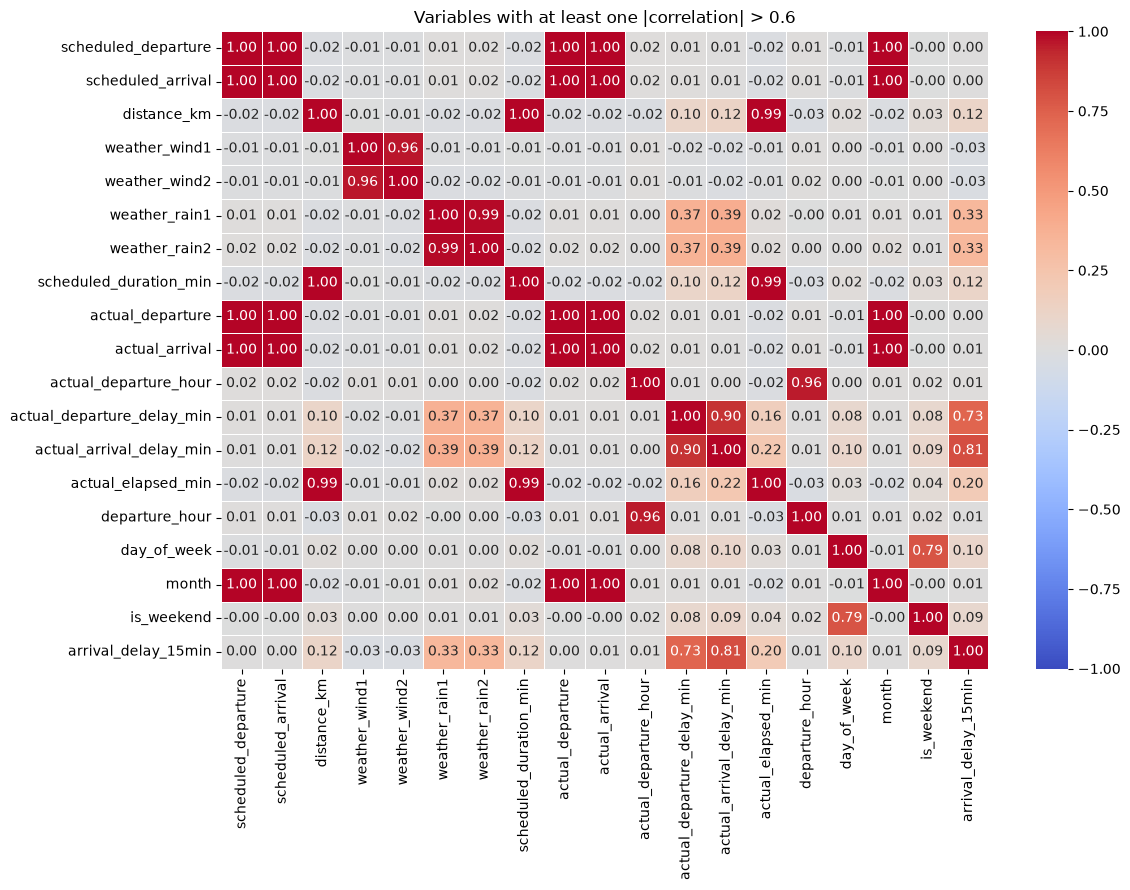

In [11]:
check_correlations(X, y)

## Data understanding and visualization

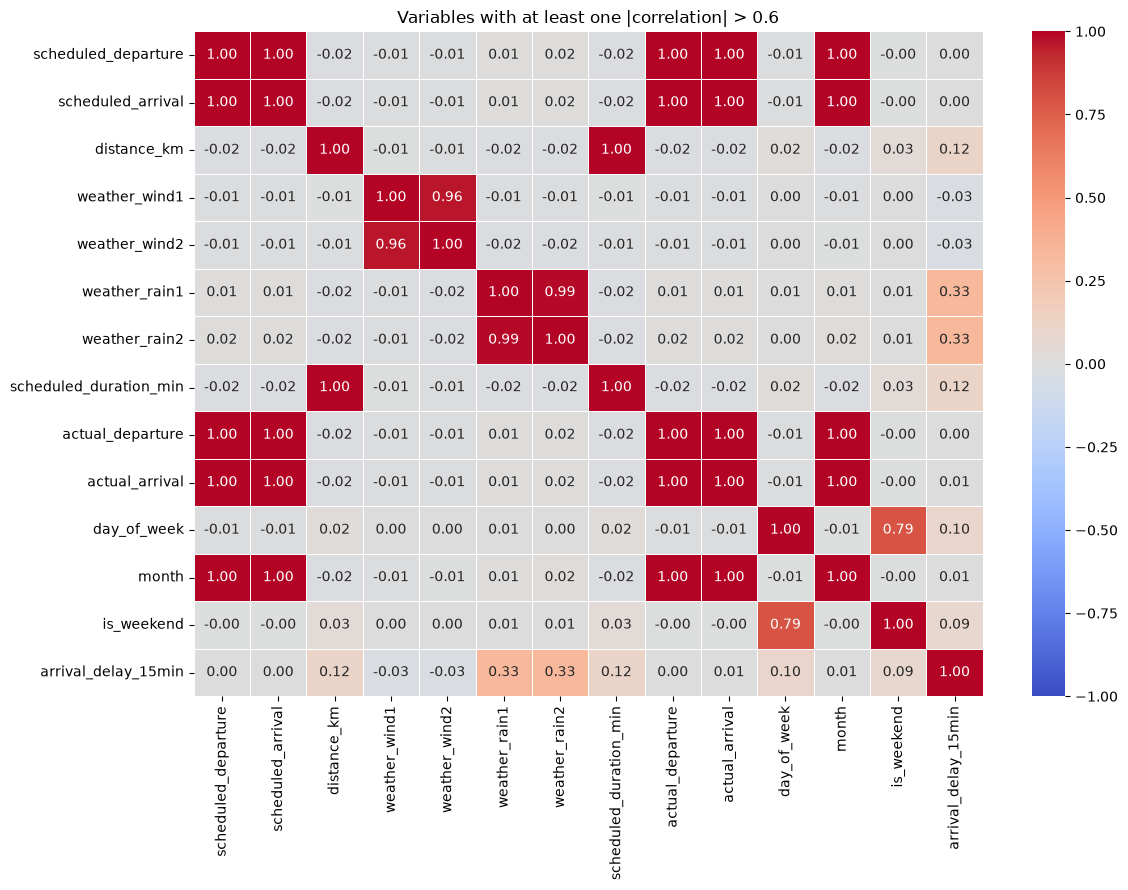

In [12]:
check_correlations(X, y, include_actual_times=False)

## 9. Actual departure and arrival times: keep or drop?

Prediction time matters:

- *Ticket sale*: route, carrier, scheduled times, and planned distance/duration.
- *Morning of travel*: forecasts and known schedule pressure.
- *Gate before departure*: current weather and operational status that is already known.
- *After departure*: actual departure time and departure delay may be inferred.
- *After landing*: actual arrival time and arrival delay are known.

For this pre-departure prediction task, `actual_departure`, `actual_arrival`, `departure_delay_min`, and `arrival_delay_min` must be dropped. The notebook keeps actual timestamps in `X` only so that we can deliberately demonstrate leakage with `include_actual_times=True`.


In [13]:
#| echo: false
# Build reusable preprocessing and classifier helpers for the later experiments.
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

def numeric_columns(X):
    return X.select_dtypes(include=np.number).columns.tolist()


def categorical_columns(X):
    return X.select_dtypes(exclude=np.number).columns.tolist()


def make_preprocessor():
    try:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([("variance", VarianceThreshold()), ("scaler", StandardScaler())]), numeric_columns),
            ("cat", one_hot, categorical_columns),
        ],
        verbose_feature_names_out=False,
    )


# def make_logistic(max_iter=1500):
#     return LogisticRegression(max_iter=max_iter, solver="liblinear", class_weight="balanced")

def make_tree(max_depth=5, min_samples_leaf=1):
    return DecisionTreeClassifier(max_depth=max_depth, min_samples_leaf=min_samples_leaf, class_weight="balanced", random_state=RANDOM_STATE)

def mutual_info_reproducible(X_array, y_array):
    return mutual_info_classif(X_array, y_array, random_state=RANDOM_STATE)


def make_pipeline(add_manual_features=False, include_actual_times=False, selector=None):
    steps = [
        ("feature_engineering", FlightFeatureEngineer(add_manual_features=add_manual_features, include_actual_times=include_actual_times)),
        ("preprocessing", make_preprocessor()),
    ]
    if selector is not None:
        steps.append(("feature_selection", selector)) # Selection is part of model fitting. Keeping it inside the pipeline prevents validation-fold information from guiding the selected features.
    steps.append(("classifier", make_tree()))
    return Pipeline(steps)

In [14]:
# Demonstrate how future information can inflate validation metrics.
leakage_demo = {
    "Raw data - no feature engineering": make_pipeline(add_manual_features=False),
    "Feature engineering": make_pipeline(add_manual_features=True),
    "Leaky feature engineering": make_pipeline(add_manual_features=True, include_actual_times=True),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "balanced_accuracy": make_scorer(balanced_accuracy_score),
    "f1": make_scorer(f1_score),
}
leakage_rows = []
for name, estimator in leakage_demo.items():
    result = cross_validate(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, return_estimator=True,)
    leakage_rows.append({
        "experiment": name,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "f1_mean": result["test_f1"].mean(),
    })

    importance_rows = []
    for fold, fitted_pipeline in enumerate(result["estimator"], start=1):
        tree = fitted_pipeline[-1]

        # Assumes the penultimate pipeline step is the fitted preprocessor.
        preprocessor = fitted_pipeline[-2]
        feature_names = preprocessor.get_feature_names_out()

        importance_rows.append(
            pd.DataFrame(
                {
                    "feature": feature_names,
                    "importance": tree.feature_importances_,
                    "fold": fold,
                }
            )
        )

        #feature_importance = (
        #    pd.concat(importance_rows)
        #    .groupby("feature", as_index=False)["importance"]
        #    .agg(["mean", "std"])
        #    .reset_index()
        #    .rename(
        #        columns={
        #            "mean": "importance_mean",
        #            "std": "importance_std",
        #        }
        #    )
        #    .sort_values("importance_mean", ascending=False)
        #)
    #display(feature_importance.head(7))


display(pd.DataFrame(leakage_rows))


,experiment,balanced_accuracy_mean,f1_mean
0,Raw data - no feature engineering,0.757822,0.702689
1,Feature engineering,0.790558,0.746087
2,Leaky feature engineering,1.000000,1.000000


## 7. Automated feature selection

We compare two families of selectors:

- **Filter methods** rank features using a statistical criterion independent of the final model. Here we use mutual information with `SelectKBest`.
    - `SelectKBest(score_func=mutual_info_classif, k=20)` estimates one mutual-information score per preprocessed feature and keeps the 20 features with the highest scores.
    - Mutual information is non-negative. A score near zero means the feature and target look almost independent under the estimator; a larger score means knowing the feature reduces more uncertainty about the class label.
    - It is univariate: each feature is scored one at a time. It can miss features that are useful only together, and it may keep redundant features if each one individually has high signal.
    - Filter methods are usually faster. *Why?*
- **Wrapper methods** search for a subset by repeatedly fitting a model. Here we use `SequentialFeatureSelector` and `RFE`.
    - Wrapper methods can capture model-specific usefulness, but they are more computationally expensive. *Why?*

Important: selection is inside the pipeline. During cross-validation, the selector is fitted only on each training fold.


In [15]:
n_features_to_select = 10

# Filter: `SelectKBest`

`SelectKBest` sorts features by the score returned by `score_func` and keeps the top `k`.

- With `mutual_info_classif`, those are the features with the highest estimated mutual information with the class label.
- This does **not** mean the selected features are causal, non-leaky, or non-redundant.
- It only means they had the largest training-fold association with `y` according to the mutual-information estimator.


In [16]:
# Score each preprocessed feature by estimated mutual information with y. Keep only the k=20 highest-scoring features inside each training fold.
filter_selector = SelectKBest(score_func=mutual_info_reproducible, k=n_features_to_select)


# Wrapper: `SequentialFeatureSelector`

Forward-SFS is a greedy procedure that iteratively finds the best new feature to add to the set of selected features. 

- Start with zero features and find the one feature that maximizes a cross-validated score when an estimator is trained on this single feature.
- Once that first feature is selected, repeat the procedure by adding a new feature to the set of selected features.
- Stop when the desired number of selected features is reached.

Backward-SFS follows the same idea but works in the opposite direction: it starts with all features and removes one feature at a time. In sklearn this is obtained with `SequentialFeatureSelector(direction="backward")`.


In [17]:
wrapper_selector = SequentialFeatureSelector(estimator=make_tree(), n_features_to_select=n_features_to_select, direction="forward", scoring="balanced_accuracy", cv=3, n_jobs=-1)


# Wrapper: `RFE`

Given an external estimator that assigns weights to features (e.g., the coefficients of a linear model), recursive feature elimination (RFE) selects features by recursively considering smaller and smaller sets of features.

- First, the estimator is trained on the initial set of features and the importance of each feature is obtained either through any specific attribute (such as coef_, feature_importances_).
- Then, the least important features are pruned from the current set of features.
- That procedure is recursively repeated on the pruned set until the desired number of features to select is eventually reached.


In [18]:
rfe_selector = RFE(estimator=make_tree(), n_features_to_select=n_features_to_select, step=0.2)

RFE vs backward `SequentialFeatureSelector`: both methods remove features until the desired subset size is reached.

- **RFE** fits the estimator and removes the least important features according to the estimator's internal importance signal. With logistic regression, this usually means small coefficient magnitudes; with trees, it may mean feature importances.
    - asks *which feature does the fitted model currently consider weakest?*
- **Backward `SequentialFeatureSelector`** tries candidate removals and evaluates the resulting model with a scoring metric, here balanced accuracy. At each step, it removes the feature whose removal gives the best cross-validated score, or hurts the score least.
    - asks *which feature can I remove while preserving validation performance?*
- Backward SFS  RFE is usually faster; backward SFS is usually more expensive but more directly tied to the chosen evaluation metric.

## 8. Compare raw, engineered, and selected feature sets

We measure predictive performance, number of selected features, and training time. We also keep the fitted estimators from cross-validation so we can inspect selection stability.

The experiment table compares predictive value, selected feature count, and runtime rather than optimizing only one number.


In [19]:
#| echo: false
# Run every feature strategy under the same stratified cross-validation protocol.

experiments = {
    "raw": make_pipeline(add_manual_features=False),
    "fe": make_pipeline(add_manual_features=True),
    "fe + wrapper (SFS)": make_pipeline(add_manual_features=True, selector=wrapper_selector),
    "fe + filter (SelectKBest)": make_pipeline(add_manual_features=True, selector=filter_selector),
    "fe + wrapper (RFE)": make_pipeline(add_manual_features=True, selector=rfe_selector),
}


def count_output_features(estimator):
    preprocessor = estimator.named_steps["preprocessing"]
    n_preprocessed = len(preprocessor.get_feature_names_out())
    selector = estimator.named_steps.get("feature_selection")
    if selector is None:
        return n_preprocessed
    return int(selector.get_support().sum())


rows = []
cv_results_by_name = {}

for name, estimator in experiments.items():
    start_time = time.perf_counter()
    result = cross_validate(estimator, X, y, cv=cv, scoring=scoring, return_estimator=True, n_jobs=-1)
    elapsed = time.perf_counter() - start_time
    cv_results_by_name[name] = result

    selected_counts = [count_output_features(fitted) for fitted in result["estimator"]]
    rows.append({
        "experiment": name,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": result["test_balanced_accuracy"].std(),
        "f1_mean": result["test_f1"].mean(),
        "features_mean": np.mean(selected_counts),
        "features_std": np.std(selected_counts),
        "fit_time_total_sec": elapsed,
    })

summary = pd.DataFrame(rows).sort_values("balanced_accuracy_mean", ascending=False)
summary

,experiment,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,features_mean,features_std,fit_time_total_sec
2,fe + wrapper (SFS),0.791582,0.020541,0.747099,10.0,0.0,9.376725
1,fe,0.790558,0.020591,0.746087,34.0,0.0,1.176897
4,fe + wrapper (RFE),0.790304,0.019633,0.745804,10.0,0.0,0.265746
3,fe + filter (SelectKBest),0.763606,0.014758,0.715857,10.0,0.0,0.503220
0,raw,0.757822,0.021924,0.702689,24.0,0.0,1.108280


## 10. Selection stability across folds

A selector is more trustworthy when it keeps similar features across folds. Instability does not always mean the selector is wrong: correlated features may be interchangeable. But instability should make us cautious when interpreting selected variables as domain truth.

Stability is an interpretation check: selected features that change across folds should be discussed cautiously.


In [20]:
#| echo: false
# Measure how similar the selected feature sets are across validation folds.
def selected_feature_names_ordered(fitted_pipeline):
    """Return feature names in the exact order seen by the final estimator."""
    names = fitted_pipeline.named_steps["preprocessing"].get_feature_names_out()
    selector = fitted_pipeline.named_steps.get("feature_selection")
    if selector is None:
        return list(names)
    return list(names[selector.get_support()])


def selected_feature_names(fitted_pipeline):
    return set(selected_feature_names_ordered(fitted_pipeline))


def mean_jaccard(selected_sets):
    scores = []
    for i in range(len(selected_sets)):
        for j in range(i + 1, len(selected_sets)):
            union = selected_sets[i] | selected_sets[j]
            intersection = selected_sets[i] & selected_sets[j]
            scores.append(len(intersection) / len(union))
    return np.mean(scores)


stability_rows = []
for name, result in cv_results_by_name.items():
    if "+" not in name:
        continue
    selected_sets = [selected_feature_names(fitted) for fitted in result["estimator"]]
    stability_rows.append({
        "experiment": name,
        "mean_jaccard_similarity": mean_jaccard(selected_sets),
        "example_selected_features": sorted(list(selected_sets[0]))[:15],
    })

stability = pd.DataFrame(stability_rows).sort_values("mean_jaccard_similarity", ascending=False)
display(stability)

,experiment,mean_jaccard_similarity,example_selected_features
2,fe + wrapper (RFE),0.760606,"[airport_SFO, departure_hour, distance_km, is_..."
1,fe + filter (SelectKBest),0.455311,"[airport_LAX, airport_SFO, carrier_AA, destina..."
0,fe + wrapper (SFS),0.431502,"[airport_ATL, airport_JFK, airport_SFO, carrie..."


## 11. Performance versus number of features

A useful visualization is a performance-versus-number-of-features curve. Here we vary `k` for `SelectKBest`. A good choice is not necessarily the highest possible balanced accuracy: we may prefer a smaller model when the performance loss is negligible.

This curve helps students look for diminishing returns as more features are selected.


,k,balanced_accuracy_mean,balanced_accuracy_std
0,5,0.728332,0.032768
1,8,0.753824,0.030965
2,12,0.767472,0.012579
3,16,0.777600,0.024921
4,20,0.781603,0.018264
5,24,0.781169,0.018387
6,28,0.781678,0.019896
7,32,0.785754,0.020080
8,36,0.790558,0.020591
9,40,0.790558,0.020591


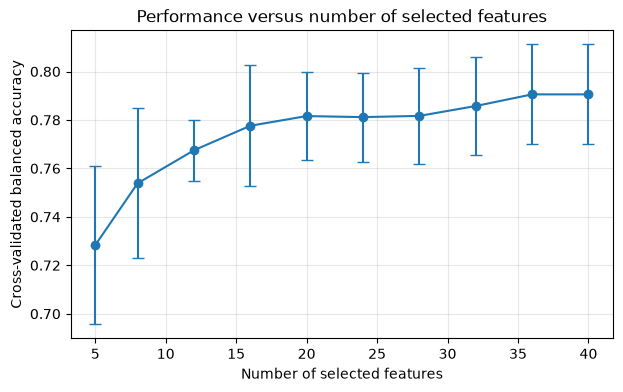

In [21]:
#| echo: false
# Vary the number of selected features to look for diminishing returns.
k_values = np.linspace(5, 40, 10, dtype=int)
curve_rows = []

for k in k_values:
    estimator = make_pipeline(
        add_manual_features=True,
        selector=SelectKBest(score_func=mutual_info_reproducible, k=k),
    )
    result = cross_validate(estimator, X, y, cv=cv, scoring={"balanced_accuracy": make_scorer(balanced_accuracy_score)}, n_jobs=-1)
    curve_rows.append({
        "k": k,
        "balanced_accuracy_mean": result["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": result["test_balanced_accuracy"].std(),
    })

curve = pd.DataFrame(curve_rows)
display(curve)

plt.figure(figsize=(7, 4))
plt.errorbar(curve["k"], curve["balanced_accuracy_mean"], yerr=curve["balanced_accuracy_std"], marker="o", capsize=4)
plt.xlabel("Number of selected features")
plt.ylabel("Cross-validated balanced accuracy")
plt.title("Performance versus number of selected features")
plt.grid(alpha=0.3)
plt.show()

## 12. Interpretability check

In [ ]:
chosen_pipeline = make_pipeline(add_manual_features=True, selector=wrapper_selector)
chosen_pipeline.fit(X, y)
selected_feature_names_for_tree = selected_feature_names_ordered(chosen_pipeline)
tree = chosen_pipeline.named_steps["classifier"]
pd.DataFrame({"selected_feature": selected_feature_names_for_tree})


,selected_feature
0,weather_rain1
1,scheduled_duration_min
2,departure_hour
3,month
4,is_weekend
5,is_holiday
6,airport_ATL
7,airport_BOS
8,airport_SFO
9,origin_SFO


## Plotting the tree

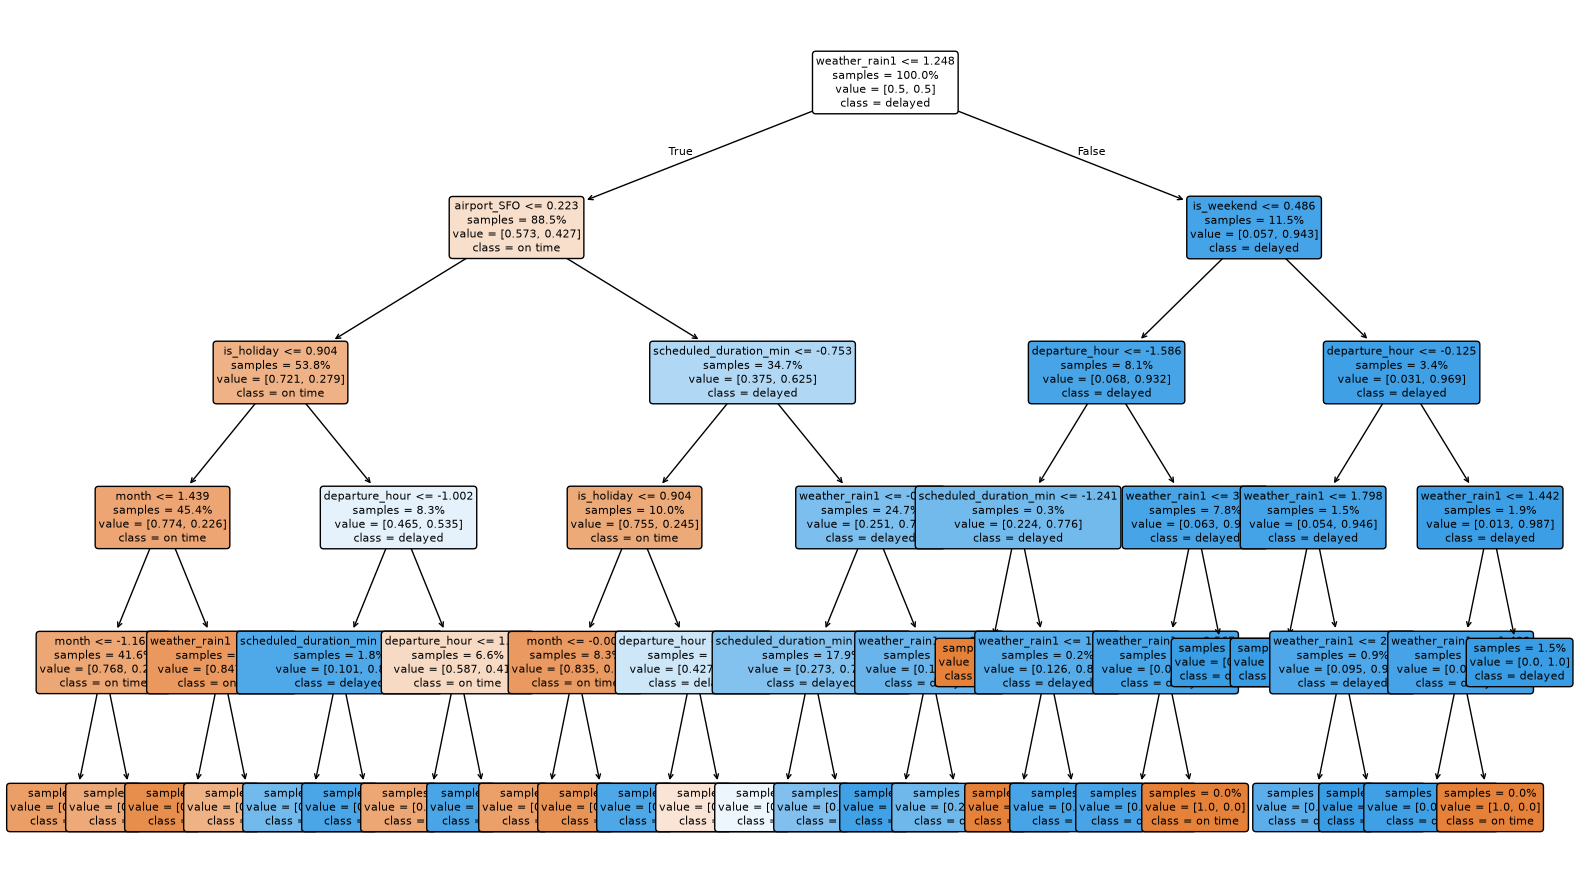

In [ ]:
#| echo: false
plt.figure(figsize=(16, 9))
plot_tree(tree, feature_names=selected_feature_names_for_tree, class_names=["on time", "delayed"], filled=True, rounded=True, proportion=True, impurity=False, fontsize=8,)
plt.tight_layout()
plt.show()

## Checking tree feature importance

In [28]:
pd.DataFrame({
    "feature": selected_feature_names_for_tree,
    "importance": tree.feature_importances_,
})

,feature,importance
0,weather_rain1,0.349957
1,scheduled_duration_min,0.184063
2,departure_hour,0.107511
3,month,0.004678
4,is_weekend,0.000431
5,is_holiday,0.093707
6,airport_ATL,0.000000
7,airport_BOS,0.000000
8,airport_SFO,0.259653
9,origin_SFO,0.000000


## Permutation importance estimates how much the fitted decision tree depends on each selected feature.

In [ ]:
#| echo: false
# Estimate importance for the exact features seen by the decision tree.
X_engineered = chosen_pipeline.named_steps["feature_engineering"].transform(X)
X_preprocessed = chosen_pipeline.named_steps["preprocessing"].transform(X_engineered)
selector = chosen_pipeline.named_steps.get("feature_selection")
X_tree = selector.transform(X_preprocessed)

importance = permutation_importance(tree, X_tree, y, scoring="balanced_accuracy", n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1,)

importance_table = (
    pd.DataFrame({
        "tree_feature": selected_feature_names_for_tree,
        "importance_mean": importance.importances_mean,
        "importance_std": importance.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
)
importance_table


,tree_feature,importance_mean,importance_std
8,airport_SFO,0.140687,0.004698
0,weather_rain1,0.104646,0.003097
1,scheduled_duration_min,0.071472,0.003180
5,is_holiday,0.042902,0.002224
2,departure_hour,0.032929,0.002506
4,is_weekend,0.000899,0.000292
3,month,0.000000,0.000000
6,airport_ATL,0.000000,0.000000
7,airport_BOS,0.000000,0.000000
9,origin_SFO,0.000000,0.000000


## 13. Student challenge

Apply feature engineering and selection to the California Housing dataset from kaggle.

- Which features are most predictive of median house value? Which features are stable across folds? Which features are redundant or noisy?